In [18]:
# Import Necessary Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
import xgboost as xgb

# Ensure SHAP plots display correctly
shap.initjs()

In [20]:
# Step 1: Load your dataset
# Replace with your actual dataset
data = pd.read_excel("Data.xlsx")


In [21]:
data.columns

Index(['Pre PCI EF', 'Age', 'Gender', 'BMI', 'waist_circ', 'Total Cholesterol',
       'Triglyceride', 'LDL', 'HDL', 'LDLtoHDL', 'FBS', 'Creatinine',
       'Hemoglobin', 'Hyperlipidemia', 'Diabetes', 'Hypertension', 'Smoking',
       'PreviousCABG', 'PreviousPCI', 'Door to Device Distance', 'MACE'],
      dtype='object')

In [24]:
data2=data.drop([], axis=1)

In [25]:
# Step 2: Separate features and target
X = data2.drop(['MACE'], axis=1)
y = data2['MACE']

In [30]:
categorical_cols = ['Gender', 'Hyperlipidemia', 'Diabetes', 'Hypertension', 'Smoking',
       'PreviousCABG', 'PreviousPCI', 'Door to Device Distance',]  # Replace with actual categorical columns
continuous_cols = ['Pre PCI EF', 'Age', 'BMI', 'waist_circ', 'Total Cholesterol',
       'Triglyceride', 'LDL', 'HDL', 'LDLtoHDL', 'FBS', 'Creatinine',
       'Hemoglobin']

In [31]:
X.columns

Index(['Pre PCI EF', 'Age', 'Gender', 'BMI', 'waist_circ', 'Total Cholesterol',
       'Triglyceride', 'LDL', 'HDL', 'LDLtoHDL', 'FBS', 'Creatinine',
       'Hemoglobin', 'Hyperlipidemia', 'Diabetes', 'Hypertension', 'Smoking',
       'PreviousCABG', 'PreviousPCI', 'Door to Device Distance'],
      dtype='object')

In [32]:
# Step 4: Encode categorical columns using LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Step 5: Scale continuous columns
scaler = StandardScaler()
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

# Step 6: Handle imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [33]:
X_resampled.head(5)

,Pre PCI EF,Age,Gender,BMI,waist_circ,Total Cholesterol,Triglyceride,LDL,HDL,LDLtoHDL,FBS,Creatinine,Hemoglobin,Hyperlipidemia,Diabetes,Hypertension,Smoking,PreviousCABG,PreviousPCI,Door to Device Distance
0,-0.650230,1.010941,1,0.567593,0.070038,0.742544,-0.046317,0.237888,0.279108,-0.084226,-0.762700,-0.117119,0.361917,0,0,0,0,0,0,0
1,0.543998,0.420845,1,-0.877994,-0.484009,0.848549,0.338776,1.665168,-1.054779,2.709955,-0.058933,0.076017,-1.405037,0,1,1,0,0,0,0
2,0.543998,-0.464299,1,1.104969,0.439403,-0.662025,-0.745190,-1.280496,0.997355,-1.490318,-0.793299,-0.358538,-0.833375,1,1,1,1,0,0,0
3,-0.053116,0.420845,0,0.278919,-0.668692,-1.245053,-1.116021,-1.553805,1.407782,-1.749182,-0.319021,0.245010,-0.261714,1,0,1,1,0,0,1
4,-0.650230,-0.316775,1,-0.569336,-1.315080,-1.218552,-0.873554,-1.128658,0.176502,-1.145501,-0.839197,-0.117119,-0.053837,0,0,0,1,0,0,2


In [34]:

# Step 7: Train-test split on resampled data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)


In [ ]:
X_train

In [35]:
# Step 8: Build and train the XGBoost model
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Step 9: Predict probabilities for class '1' on test data
predicted_probs = model.predict_proba(X_test)[:, 1]  # Probability for class '1'

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [22:41:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [36]:
X_test.columns

Index(['Pre PCI EF', 'Age', 'Gender', 'BMI', 'waist_circ', 'Total Cholesterol',
       'Triglyceride', 'LDL', 'HDL', 'LDLtoHDL', 'FBS', 'Creatinine',
       'Hemoglobin', 'Hyperlipidemia', 'Diabetes', 'Hypertension', 'Smoking',
       'PreviousCABG', 'PreviousPCI', 'Door to Device Distance'],
      dtype='object')

In [37]:
#probs=pd.DataFrame(predicted_probs)

In [38]:
#probs.to_excel("probs.xlsx")

In [39]:
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

In [40]:
y_test.shape

(724,)

In [41]:
y_train.shape

(1688,)

In [42]:
# Evaluate the model
y_pred = (model.predict(X_test) > 0.5).astype(int)
y_pred_proba=model.predict(X_test)

In [43]:

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

# Calculate the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Sensitivity (Recall), Specificity, PPV, NPV
sensitivity = tp / (tp + fn)  # Sensitivity or Recall
specificity = tn / (tn + fp)  # Specificity
ppv = tp / (tp + fp)          # Positive Predictive Value (PPV)
npv = tn / (tn + fn)          # Negative Predictive Value (NPV)

# Likelihood Ratios
lr_positive = sensitivity / (1 - specificity)  # Positive Likelihood Ratio
lr_negative = (1 - sensitivity) / specificity  # Negative Likelihood Ratio

# Print metrics
print(f'Accuracy: {accuracy}')
print(f'Balanced Accuracy: {balanced_acc}')
print(f'Sensitivity (Recall): {sensitivity}')
print(f'Specificity: {specificity}')
print(f'PPV: {ppv}')
print(f'NPV: {npv}')
print(f'Likelihood Ratio Positive: {lr_positive}')
print(f'Likelihood Ratio Negative: {lr_negative}')


Accuracy: 0.8922651933701657
Balanced Accuracy: 0.8922813873961895
Sensitivity (Recall): 0.8932584269662921
Specificity: 0.8913043478260869
PPV: 0.888268156424581
NPV: 0.8961748633879781
Likelihood Ratio Positive: 8.217977528089884
Likelihood Ratio Negative: 0.11975883803781863


In [44]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, predicted_probs)


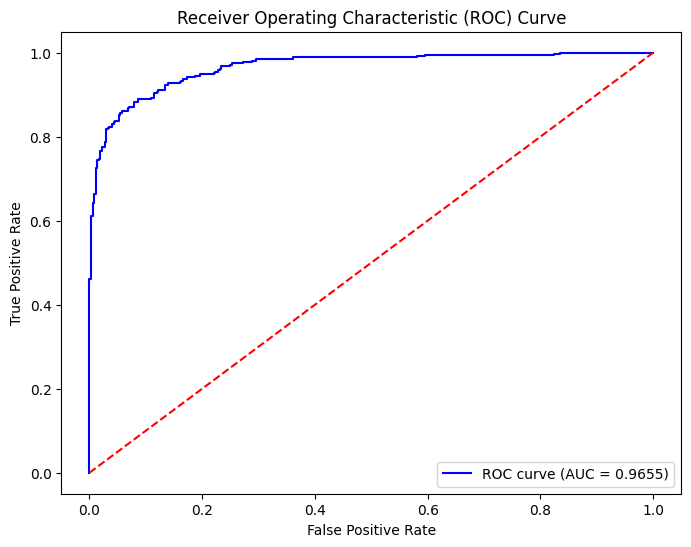

In [45]:
from sklearn.metrics import roc_curve, auc
# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, predicted_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [46]:
roc_auc

0.9655440889106008

In [47]:
# Step 10: Create SHAP explainer and generate SHAP values
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

In [48]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Instantiate the XGBoost classifier
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',  # For binary classification (modify if multi-class)
    scale_pos_weight=len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1]),  # Handling imbalance
    eval_metric='auc',
    use_label_encoder=False
)

# Train the model
xgb_clf.fit(X_train, y_train)

# Predictions
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:, 1]  # For ROC-AUC

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Detailed classification report
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [22:41:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.8923
ROC AUC: 0.9655
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       368
           1       0.89      0.89      0.89       356

    accuracy                           0.89       724
   macro avg       0.89      0.89      0.89       724
weighted avg       0.89      0.89      0.89       724



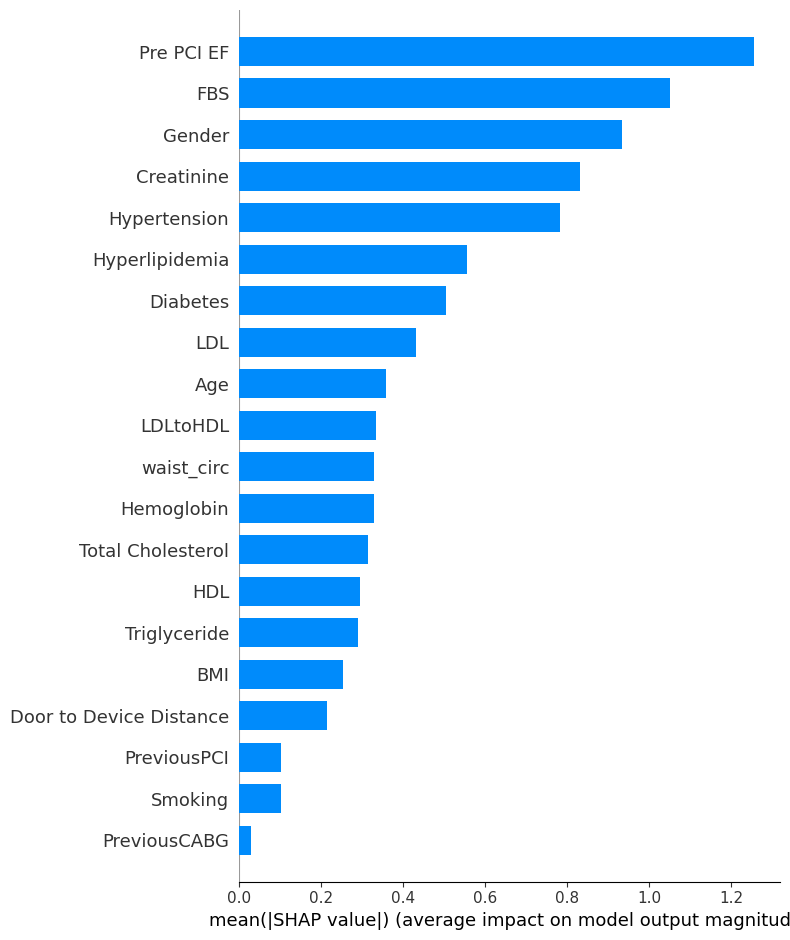

In [49]:
import shap

# SHAP requires a small subset of data for performance reasons
explainer = shap.Explainer(xgb_clf)
shap_values = explainer(X_test)

# Summary plot - global feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [50]:
X_test

,Pre PCI EF,Age,Gender,BMI,waist_circ,Total Cholesterol,Triglyceride,LDL,HDL,LDLtoHDL,FBS,Creatinine,Hemoglobin,Hyperlipidemia,Diabetes,Hypertension,Smoking,PreviousCABG,PreviousPCI,Door to Device Distance
1621,-2.255731,0.981598,1,-0.376951,-0.949965,0.178698,0.254224,-0.430367,-0.507730,-0.272280,-0.358015,0.640396,-1.360628,1,0,1,1,0,0,106
2200,-0.789396,0.047039,0,-0.966244,-0.320848,-0.983823,-0.506692,-1.103311,-0.964502,-0.445610,-0.531484,-0.040702,-0.456683,0,0,0,0,0,0,19
2399,-1.398015,-0.758757,1,1.349748,0.715319,-0.172228,0.075135,0.100687,-0.285434,0.160206,0.201196,-0.116475,0.102140,0,1,0,0,0,0,38
1953,-0.030311,0.015412,1,-1.757376,-1.968522,-0.445139,-0.489106,-0.161744,-0.324776,-0.078597,-0.054604,-0.832156,-0.725831,0,0,0,0,0,0,43
1798,0.019092,-0.388134,1,-1.615727,-1.821453,-0.656727,-0.258998,-0.720462,0.783076,-1.007061,0.731224,-1.130519,0.171201,0,0,0,0,0,0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2055,0.114080,1.158465,1,-1.218185,-1.004814,-0.956718,-0.589442,-0.617263,-0.389885,-0.453211,-0.580331,0.896846,-0.463361,0,0,0,0,0,0,130
998,0.543998,0.420845,0,-0.540469,-0.484009,-1.722077,-0.787978,-2.161159,0.894749,-2.085035,-0.257824,5.194105,-3.743653,0,0,0,0,0,1,73
859,-0.053116,-0.464299,0,1.677875,0.531744,-0.078996,0.895022,-0.308731,-1.157386,0.524848,-0.517912,1.331397,-1.145191,1,1,1,0,0,0,59
429,0.245441,-0.759347,1,0.050201,0.070038,0.345024,-0.916343,0.541564,0.894749,-0.187769,0.109360,-0.406822,0.621763,1,1,1,0,0,0,32


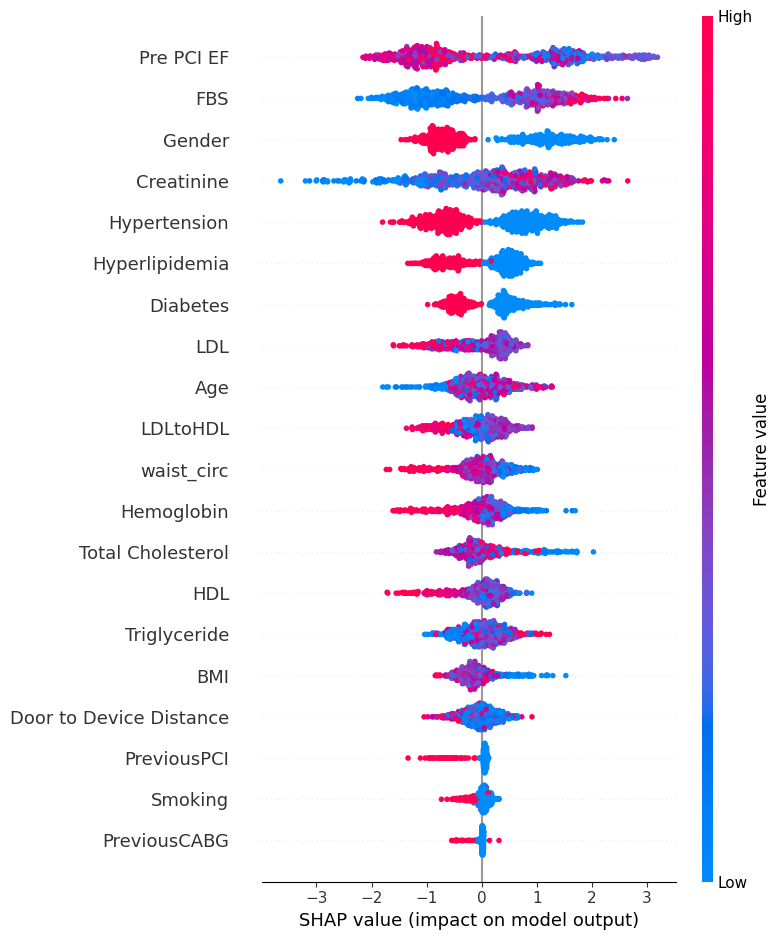

In [51]:

# 5. SHAP Beeswarm Plot (P Swarm Plot)
# Shows distribution of SHAP values for each feature
shap.summary_plot(shap_values, X_test)

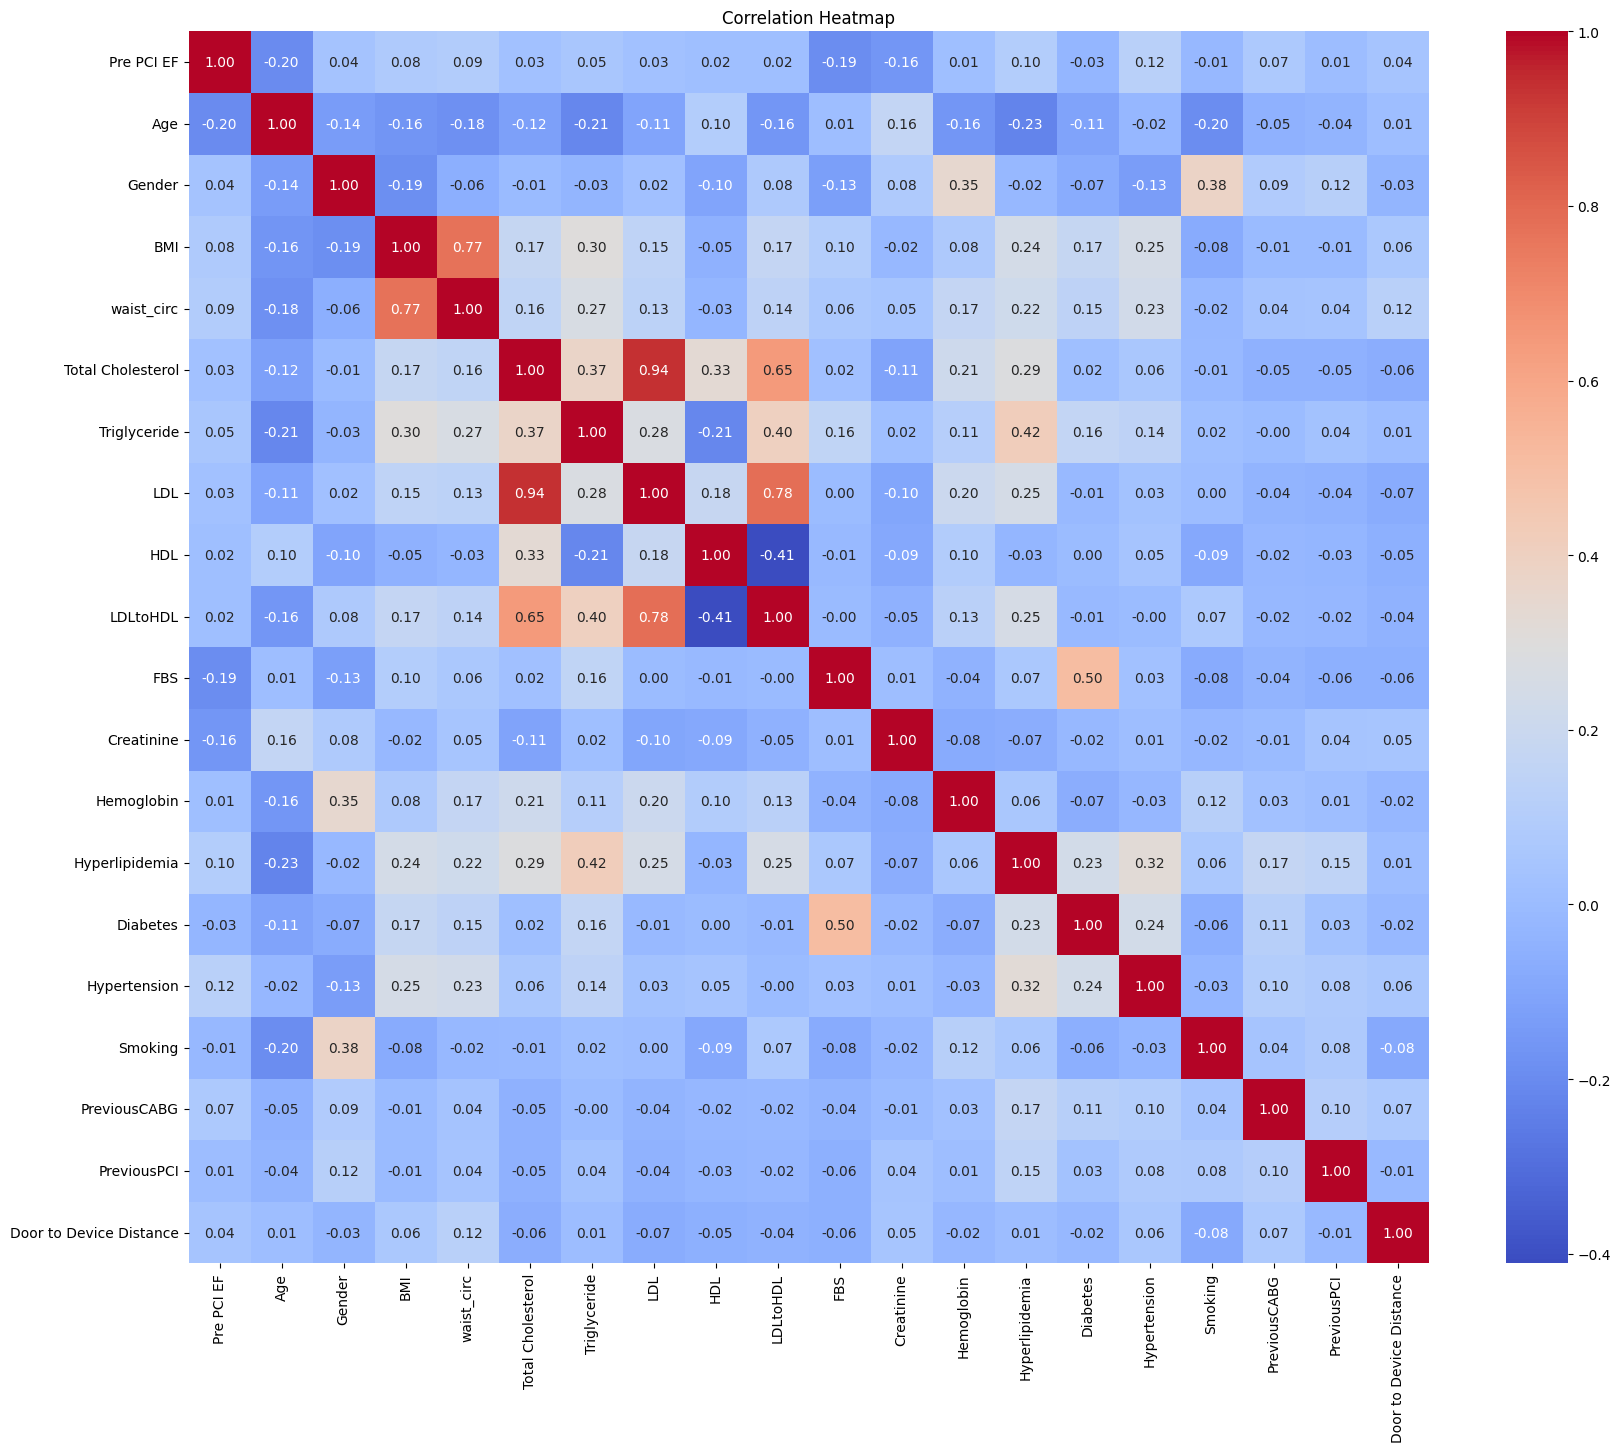

In [52]:

# Step 11: Extract SHAP values for the positive class (class 1)
shap_values_class_1 = shap_values[..., 1]  # SHAP values for predicted probabilities of class '1'

# Visualizations
# Step 12: Correlation Heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(pd.DataFrame(X_train, columns=X.columns).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


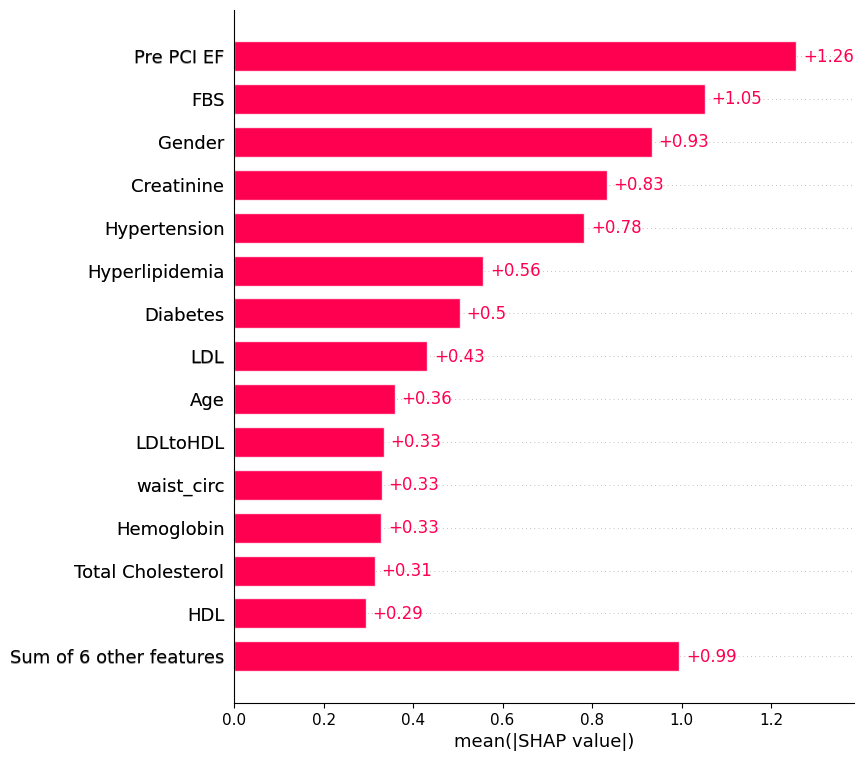

In [53]:
# 7. Bar Absolute Mean SHAP Plot (Feature Importance by Contribution)
# Bar plot showing the absolute mean SHAP values (to highlight feature importance)
shap.plots.bar(shap_values, max_display=15)